# Credit Score Classification

## Objective
The primary objective of this project is to develop a machine learning model that accurately classifies individuals into predefined credit score categories based on various features available in the dataset. The end goal is to create a tool that can help financial institutions assess the creditworthiness of their clients efficiently and reliably.

# Features Description

- **ID**: A unique identifier for each entry in the dataset.

- **Customer_ID**: A unique identifier for each customer. This is used to track individual credit records.

- **Month**: The transaction or record month. Useful for temporal analysis to track scores over time.

- **Name**: The name of the customer. Generally not used for modeling but may be used for descriptive purposes.

- **Age**: The age of the customer. Age could be a significant factor in determining credit risk.

- **SSN**: Social Security Number. Typically, not used directly in modeling but important for identification and verification processes.

- **Occupation**: The occupation of the customer. Different occupation types can have varying default risk associated with them.

- **Annual_Income**: The total yearly income of the customer. A key factor in determining an individual's ability to repay loans.

- **Monthly_Inhand_Salary**: The salary in-hand received monthly after deductions. Important for assessing cash flow and repayment capacity.

- **Num_Bank_Accounts**: Total number of bank accounts the customer has. Reflects financial behavior and stability.

- **Num_Credit_Card**: The number of credit cards held by the customer. Related to credit exposure and spending habits.

- **Interest_Rate**: The interest rate applicable on loans or credit cards. Influences the customer’s repayment burden.

- **Num_of_Loan**: The total number of loans the customer has. Shows the level of indebtedness.

- **Type_of_Loan**: The types of loans held by the customer (e.g., personal, auto, mortgage). Different loan types carry different risks.

- **Delay_from_due_date**: Average delay in days for payments past due date. Indicative of payment habits and reliability.

- **Num_of_Delayed_Payment**: Number of payments delayed beyond due dates. Impacts credit score directly.

- **Changed_Credit_Limit**: Changes in credit limits. Could indicate changes in perceived creditworthiness or attempts to manage debts.

- **Num_Credit_Inquiries**: Number of times the credit report has been pulled. A high number might indicate financial distress or credit shopping.

- **Credit_Mix**: The variety of credit types the customer has (e.g., cards, mortgages, installment loans). Diversity can be positive or negative.

- **Outstanding_Debt**: The total debt remaining unpaid. High debt indicates higher risk.

- **Credit_Utilization_Ratio**: The percentage of credit used out of the total available credit limit. Higher ratios suggest greater risk.

- **Credit_History_Age**: The age of the customer’s oldest credit account, usually in years and months. Longer histories typically boast better scores.

- **Payment_of_Min_Amount**: Whether the customer makes only the minimum monthly payment. Shows risk-averse behavior.

- **Total_EMI_per_month**: The total Equated Monthly Installment paid across all loans. Determines monthly financial burden.

- **Amount_invested_monthly**: The amount the customer invests monthly. Suggests savings habits and financial health.

- **Payment_Behaviour**: General payment behavior and patterns. A qualitative measure of reliability.

- **Monthly_Balance**: The balance remaining after monthly expenses. Indicates cash flow and financial stability.


## Target
The target variable for this classification problem is the credit score category, which segments individuals according to their creditworthiness. The categories may include, but are not limited to:
- **Good**: Represents individuals who have a high credit score and are likely to meet their credit obligations.
- **Average**: Represents individuals with a medium-range credit score, indicating moderate creditworthiness.
- **Poor**: Represents individuals with a low credit score, suggesting a higher risk of default.

The model will be trained to assign each individual in the dataset to one of these categories based on the input features.

# 01. Import Necessary Libraries

- Default Libraries

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import ast


- Additional Libraries

In [5]:
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, LabelEncoder, MultiLabelBinarizer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from xgboost import plot_importance
from sklearn.model_selection import cross_val_score, KFold, RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.metrics import f1_score, precision_score, recall_score
import warnings
warnings.filterwarnings('ignore')

----------------
# 02. Load Data

In [6]:
train = pd.read_csv("/content/train.csv")

----------------
# 03. Exploratory Data Analysis (EDA)

## `i` Simple Analysis

In [7]:
train.shape

(100000, 28)

In [8]:
train.head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good


In [9]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month                     100000 non-null  object 
 3   Name                      90015 non-null   object 
 4   Age                       100000 non-null  object 
 5   SSN                       100000 non-null  object 
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  object 
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  object 
 13  Type_of_Loan              88592 non-null   ob

In [10]:
train.describe()

,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Delay_from_due_date,Num_Credit_Inquiries,Credit_Utilization_Ratio,Total_EMI_per_month
count,84998.000000,100000.000000,100000.00000,100000.000000,100000.000000,98035.000000,100000.000000,100000.000000
mean,4194.170850,17.091280,22.47443,72.466040,21.068780,27.754251,32.285173,1403.118217
std,3183.686167,117.404834,129.05741,466.422621,14.860104,193.177339,5.116875,8306.041270
min,303.645417,-1.000000,0.00000,1.000000,-5.000000,0.000000,20.000000,0.000000
25%,1625.568229,3.000000,4.00000,8.000000,10.000000,3.000000,28.052567,30.306660
50%,3093.745000,6.000000,5.00000,13.000000,18.000000,6.000000,32.305784,69.249473
75%,5957.448333,7.000000,7.00000,20.000000,28.000000,9.000000,36.496663,161.224249
max,15204.633333,1798.000000,1499.00000,5797.000000,67.000000,2597.000000,50.000000,82331.000000


In [11]:
train.isnull().sum()

,0
ID,0
Customer_ID,0
Month,0
Name,9985
Age,0
SSN,0
Occupation,0
Annual_Income,0
Monthly_Inhand_Salary,15002
Num_Bank_Accounts,0


- **'Name'** Missing values: 9985 -> ignore that because we will drop the column anyway.
- **'Monthly_Inhand_Salary'** Missing values: 15002 -> We can group customers by their jobs and take the mean of monthly salary then fill the null values with.
- **'Type_of_Loan'** Missing values: 11408 -> We can fill in with the most common loan.
- **'Num_of_Delayed_Payment'** Missing values: 7002
- **'Num_Credit_Inquiries'** Missing values: 1965
- **'Credit_History_Age'** Missing values: 9030
- **'Amount_invested_monthly'** Missing values: 4479
- **'Monthly_Balance'** Missing values: 1200

In [12]:
train.duplicated().sum()

np.int64(0)

Check the unknown symbols and unclean data, and wrong patterns to handle them.

In [13]:
int_cols = train.select_dtypes(include=['int64', 'float64']).columns

In [14]:
list_of_cols = [col for col in train.columns if col not in ['ID', 'Customer_ID', 'SSN'] + list(int_cols)]

for col in list_of_cols:
    if train[col].dtype == 'object':
        print(f"Column: {col}")
        print(f"Unique values: {train[col].unique()[:10]}")
        print(f"Missing values: {train[col].isnull().sum()}")
        print("-" * 50)

Column: Month
Unique values: ['January' 'February' 'March' 'April' 'May' 'June' 'July' 'August']
Missing values: 0
--------------------------------------------------
Column: Name
Unique values: ['Aaron Maashoh' nan 'Rick Rothackerj' 'Langep' 'Jasond' 'Deepaa' 'Np'
 'Nadiaq' 'Annk' 'Charlie Zhur']
Missing values: 9985
--------------------------------------------------
Column: Age
Unique values: ['23' '-500' '28_' '28' '34' '54' '55' '21' '31' '33']
Missing values: 0
--------------------------------------------------
Column: Occupation
Unique values: ['Scientist' '_______' 'Teacher' 'Engineer' 'Entrepreneur' 'Developer'
 'Lawyer' 'Media_Manager' 'Doctor' 'Journalist']
Missing values: 0
--------------------------------------------------
Column: Annual_Income
Unique values: ['19114.12' '34847.84' '34847.84_' '143162.64' '30689.89' '30689.89_'
 '35547.71_' '35547.71' '73928.46' '131313.4']
Missing values: 0
--------------------------------------------------
Column: Num_of_Loan
Unique values

In [15]:
check_cols = ['Monthly_Balance', 'Amount_invested_monthly', 'Outstanding_Debt']

In [16]:
for col in check_cols:
    # Print unique non-numeric values in each column
    non_numeric = train[~train[col].astype(str).str.replace('.', '', 1).str.replace('-', '', 1).str.isdigit()][col].unique()[:10]
    print(f"Column: {col}")
    print(f"Non-numeric values: {non_numeric}")
    print("-" * 50)

Column: Monthly_Balance
Non-numeric values: [nan '__-333333333333333333333333333__']
--------------------------------------------------
Column: Amount_invested_monthly
Non-numeric values: ['__10000__' nan]
--------------------------------------------------
Column: Outstanding_Debt
Non-numeric values: ['1328.93_' '1283.37_' '2797.17_' '3818.57_' '343.84_' '363.51_' '404.51_'
 '1755.81_' '2593.44_' '89.62_']
--------------------------------------------------


In [17]:
integer_columns = ['Age', 'Annual_Income', 'Num_of_Loan','Num_of_Delayed_Payment',
                   'Changed_Credit_Limit','Outstanding_Debt', 'Amount_invested_monthly', 'Monthly_Balance']

for col in integer_columns:
    # Coerce conversion to numeric (invalid parsing becomes NaN)
    coerced = pd.to_numeric(train[col], errors='coerce')

    # Mask where original value is not numeric but not NaN in original column
    mask = coerced.isna() & train[col].notna()

    invalid_values = train.loc[mask, col].unique()

    print(f"\nColumn: {col}")
    print("Invalid values found:")
    print(invalid_values)
    print(f"Number of invalid entries: {mask.sum()}")
    print("-" * 50)



Column: Age
Invalid values found:
['28_' '34_' '30_' '24_' '33_' '35_' '31_' '40_' '37_' '54_' '21_' '20_'
 '43_' '38_' '18_' '2111_' '46_' '16_' '19_' '47_' '53_' '25_' '27_' '55_'
 '42_' '48_' '49_' '50_' '32_' '22_' '17_' '29_' '15_' '51_' '26_' '39_'
 '14_' '36_' '44_' '7670_' '45_' '23_' '41_' '52_' '733_' '5769_' '4383_'
 '56_' '2650_' '3307_' '6962_' '5589_' '6556_' '1447_' '8153_' '3834_'
 '6744_' '6471_' '7723_' '7640_' '6408_' '3502_' '7316_' '1102_' '8669_'
 '2463_' '6666_' '3055_' '1248_' '2220_' '2159_' '4583_' '3988_' '2155_'
 '6770_' '1843_' '1367_' '3742_' '2171_' '5109_' '3984_' '2474_' '5046_'
 '7715_' '2329_' '707_' '844_' '2756_' '2037_' '902_' '8523_' '3640_'
 '3998_' '3712_' '2097_' '8348_' '5373_' '3291_' '2994_' '3339_' '2812_'
 '3578_' '3564_' '1794_' '737_' '4301_' '2846_' '2373_' '1188_' '8207_'
 '5909_' '6381_' '8616_' '6799_' '1591_' '3775_' '6564_' '7122_' '4913_'
 '5697_' '3843_' '4445_' '6921_' '780_' '1070_' '5798_' '4808_']
Number of invalid entries: 

#### > Handling Underscore (`_`) Symbols in Columns

The dataset contains underscore (`_`) symbols in various columns. These symbols should be either removed or replaced with appropriate values based on the context of each column.

#### > Column-wise Cleaning Strategy

- **Age** : Remove `_`
- **Occupation** : Remove `_` or fill with `NULL`
- **Annual_Income** : Remove `_` or fill with `NULL` if there is no numeric value
- **Num_of_Loan** : Remove `_` or fill with `NULL` if there is no numeric value
- **Num_of_Delayed_Payment** : Remove `_` or fill with `NULL` if there is no numeric value
- **Changed_Credit_Limit** : Remove `_` or fill with `NULL` if there is no numeric value
- **Credit_Mix** : Fill `_` with `NULL`
- **Monthly_Balance** : Remove `_` or fill with `NULL` if there is no numeric value
- **Amount_invested_monthly** : Remove `_` or fill with `NULL` if there is no numeric value
- **Outstanding_Debt** : Remove `_` or fill with `NULL` if there is no numeric value
- **Payment_Behaviour** : Clear strings like `!@9#%8`

#### > Additional EDA insights:

- **Type_of_Loan** : Contains long strings with multiple loan types. These should be converted into a list of individual loan types.

  **Ex**:  `"Auto Loan, and Student Loan"` → `['Auto Loan', 'Student Loan']`

- **Age** : has unlogcal values

- **Credit_History_Age**: Need to change it to numeric value

- **Drop coulms**: ID, Customer_ID, Month, Name, SSN

- **Payment_of_Min_Amount**: replace `NM` with Null

## `ii` Cleaning data

In [18]:
# Remove non-numeric characters
train['Age'] = train['Age'].astype(str).str.extract(r'(\d+)')

# Convert Age to numeric type
train['Age'] = pd.to_numeric(train['Age'], errors='coerce')

# Check the data type of Age
train.Age.dtype

dtype('int64')

In [19]:
train['Age'].max(), train['Age'].min()

(8698, 14)

`'Age'` has unrealistic numbers, we can cap it to avoid outlier numbers

In [20]:
# Remove unwant characters and fill the value with null if it is empty
train['Occupation'] = train['Occupation'].astype(str).str.replace(r'[^a-zA-Z\s]', '', regex=True).replace('', np.nan)

# Check unique values in the Occupation column
print(train['Occupation'].unique())

# Check for missing values in the Occupation column
print("Number of missing values: ", train['Occupation'].isnull().sum())

['Scientist' nan 'Teacher' 'Engineer' 'Entrepreneur' 'Developer' 'Lawyer'
 'MediaManager' 'Doctor' 'Journalist' 'Manager' 'Accountant' 'Musician'
 'Mechanic' 'Writer' 'Architect']
Number of missing values:  7062


In [21]:
# Remove non-numeric characters and fill the value with null if it is empty
train['Annual_Income'] = train['Annual_Income'].astype(str).str.replace(r'[^0-9.]', '', regex=True).replace('', np.nan)

# Convert Annual_Income to numeric type
train['Annual_Income'] = pd.to_numeric(train['Annual_Income'], errors='coerce')

# Check the data type of Annual_Income
print(train.Annual_Income.dtype)

# Check for missing values in Annual_Income
print("Number of missing values in 'Annual_Income':", train['Annual_Income'].isnull().sum())


float64
Number of missing values in 'Annual_Income': 0


In [22]:
# Remove non-numeric characters and fill the value with null if it is empty
train['Num_of_Loan'] = train['Num_of_Loan'].astype(str).str.replace(r'[^0-9]', '', regex=True).replace('', np.nan)

# Convert Num_of_Loan to numeric type
train['Num_of_Loan'] = pd.to_numeric(train['Num_of_Loan'], errors='coerce')

# Check the data type of Num_of_Loan
print(train.Num_of_Loan.dtype)

# Check for missing values in Num_of_Loan
print("Number of missing values in 'Num_of_Loan':", train['Num_of_Loan'].isnull().sum())

int64
Number of missing values in 'Num_of_Loan': 0


In [23]:
# Remove non-numeric characters and fill the value with null if it is empty
train['Num_of_Delayed_Payment'] = train['Num_of_Delayed_Payment'].astype(str).str.replace(r'[^0-9]', '', regex=True).replace('', np.nan)

# Convert Num_of_Delayed_Payment to numeric type
train['Num_of_Delayed_Payment'] = pd.to_numeric(train['Num_of_Delayed_Payment'], errors='coerce')

# Check the data type of Num_of_Delayed_Payment
print(train.Num_of_Delayed_Payment.dtype)

# Check for missing values in Num_of_Loan
print("Number of missing values in 'Num_of_Delayed_Payment':", train['Num_of_Delayed_Payment'].isnull().sum())


float64
Number of missing values in 'Num_of_Delayed_Payment': 7002


In [24]:
# Remove non-numeric characters and fill the value with null if it is empty
train['Changed_Credit_Limit'] = train['Changed_Credit_Limit'].astype(str).str.replace(r'[^0-9]', '', regex=True).replace('', np.nan)

# Convert Changed_Credit_Limit to numeric type
train['Changed_Credit_Limit'] = pd.to_numeric(train['Changed_Credit_Limit'], errors='coerce')

# Check the data type of Changed_Credit_Limit
print(train.Changed_Credit_Limit.dtype)

# Check for missing values in Changed_Credit_Limit
print("Number of missing values in 'Changed_Credit_Limit':", train['Changed_Credit_Limit'].isnull().sum())

float64
Number of missing values in 'Changed_Credit_Limit': 2091


In [25]:
# Rramove unwant characters and fill the value with null if it is empty
train['Credit_Mix'] = train['Credit_Mix'].astype(str).str.replace(r'[^a-zA-Z\s]', '', regex=True).replace('', np.nan)

# Check unique values in the Credit_Mix column
print(train['Credit_Mix'].unique())

# Check for missing values in the Credit_Mix column
print("Number of missing values: ", train['Credit_Mix'].isnull().sum())

[nan 'Good' 'Standard' 'Bad']
Number of missing values:  20195


In [26]:
# Remove non-numeric characters and fill the value with null if it is empty
train['Monthly_Balance'] = train['Monthly_Balance'].astype(str).str.replace(r'[^0-9.]', '', regex=True).replace('', np.nan)

# Convert Monthly_Balance to numeric type
train['Monthly_Balance'] = pd.to_numeric(train['Monthly_Balance'], errors='coerce')

# Check the data type of Monthly_Balance
print(train.Monthly_Balance.dtype)

# Check for missing values in Monthly_Balance
print("Number of missing values in 'Monthly_Balance':", train['Monthly_Balance'].isnull().sum())

float64
Number of missing values in 'Monthly_Balance': 1200


In [27]:
# Remove non-numeric characters and fill the value with null if it is empty
train['Amount_invested_monthly'] = train['Amount_invested_monthly'].astype(str).str.replace(r'[^0-9.]', '', regex=True).replace('', np.nan)

# Convert Amount_invested_monthly to numeric type
train['Amount_invested_monthly'] = pd.to_numeric(train['Amount_invested_monthly'], errors='coerce')

# Check the data type of Amount_invested_monthly
print(train.Amount_invested_monthly.dtype)

# Check for missing values in Amount_invested_monthly
print("Number of missing values in 'Amount_invested_monthly':", train['Amount_invested_monthly'].isnull().sum())

float64
Number of missing values in 'Amount_invested_monthly': 4479


In [28]:
# Remove non-numeric characters and fill the value with null if it is empty
train['Outstanding_Debt'] = train['Outstanding_Debt'].astype(str).str.replace(r'[^0-9.]', '', regex=True).replace('', np.nan)

# Convert Outstanding_Debt to numeric type
train['Outstanding_Debt'] = pd.to_numeric(train['Outstanding_Debt'], errors='coerce')

# Check the data type of Outstanding_Debt
print(train.Outstanding_Debt.dtype)

# Check for missing values in Outstanding_Debt
print("Number of missing values in 'Outstanding_Debt':", train['Outstanding_Debt'].isnull().sum())

float64
Number of missing values in 'Outstanding_Debt': 0


In [29]:
# Remove unwanted special characters from 'Payment_Behaviour'
train['Payment_Behaviour'] = train['Payment_Behaviour'].astype(str).str.replace(r'[^a-zA-Z\s]', '', regex=True).replace('', np.nan)

# Check unique values in the Payment_Behaviour column
print(train['Payment_Behaviour'].unique())

# Check for missing values in the Payment_Behaviour column
print("Number of missing values in 'Payment_Behaviour':", train['Payment_Behaviour'].isnull().sum())

['HighspentSmallvaluepayments' 'LowspentLargevaluepayments'
 'LowspentMediumvaluepayments' 'LowspentSmallvaluepayments'
 'HighspentMediumvaluepayments' nan 'HighspentLargevaluepayments']
Number of missing values in 'Payment_Behaviour': 7600


In [30]:
# Convert 'Type_of_Loan' strings to lists of individual loan types
def split_loan_types(val):
    if pd.isnull(val):
        return np.nan
    # Replace ', and' and ' and' with ',' for consistent splitting
    val = val.replace(', and', ',').replace(' and', ',')
    # Split by ',' and strip whitespace
    return [x.strip() for x in val.split(',') if x.strip()]

train['Type_of_Loan'] = train['Type_of_Loan'].apply(split_loan_types)

# Check the transformation
print(train['Type_of_Loan'].head())

0    [Auto Loan, Credit-Builder Loan, Personal Loan...
1    [Auto Loan, Credit-Builder Loan, Personal Loan...
2    [Auto Loan, Credit-Builder Loan, Personal Loan...
3    [Auto Loan, Credit-Builder Loan, Personal Loan...
4    [Auto Loan, Credit-Builder Loan, Personal Loan...
Name: Type_of_Loan, dtype: object


In [31]:
# Collect all unique loan types from the lists in 'Type_of_Loan'
unique_loan_types = set()
for loan_list in train['Type_of_Loan'].dropna():
    for loan in loan_list:
        unique_loan_types.add(loan)

print("Unique loan types in 'Type_of_Loan':")
for loan in sorted(unique_loan_types):
    print(loan)

Unique loan types in 'Type_of_Loan':
Auto Loan
Credit-Builder Loan
Debt Consolidation Loan
Home Equity Loan
Mortgage Loan
Not Specified
Payday Loan
Personal Loan
Student Loan


In [32]:
def clean_loan_types(loan_list):
    if isinstance(loan_list, list):
        # Remove duplicates
        unique_types = list(dict.fromkeys(loan_list))
        # If 'Not Specified' is present with other types, remove it
        if 'Not Specified' in unique_types and len(unique_types) > 1:
            unique_types = [lt for lt in unique_types if lt != 'Not Specified']
        return unique_types
    return loan_list

train['Type_of_Loan'] = train['Type_of_Loan'].apply(clean_loan_types)

# Check the transformation
print(train['Type_of_Loan'].head(10))

0    [Auto Loan, Credit-Builder Loan, Personal Loan...
1    [Auto Loan, Credit-Builder Loan, Personal Loan...
2    [Auto Loan, Credit-Builder Loan, Personal Loan...
3    [Auto Loan, Credit-Builder Loan, Personal Loan...
4    [Auto Loan, Credit-Builder Loan, Personal Loan...
5    [Auto Loan, Credit-Builder Loan, Personal Loan...
6    [Auto Loan, Credit-Builder Loan, Personal Loan...
7    [Auto Loan, Credit-Builder Loan, Personal Loan...
8                                [Credit-Builder Loan]
9                                [Credit-Builder Loan]
Name: Type_of_Loan, dtype: object


In [33]:
# Replace 'NM' with NaN in 'Payment_of_Min_Amount'
train['Payment_of_Min_Amount'] = train['Payment_of_Min_Amount'].replace('NM', np.nan)

# Check the unique values and missing count after replacement
print(train['Payment_of_Min_Amount'].unique())
print("Number of missing values in 'Payment_of_Min_Amount':", train['Payment_of_Min_Amount'].isnull().sum())

['No' nan 'Yes']
Number of missing values in 'Payment_of_Min_Amount': 12007


In [34]:
# check and sum null values in each column and the ratio of missing values
missing_values = train.isnull().sum()
missing_ratio = missing_values / len(train) * 100
missing_df = pd.DataFrame({'Missing Values': missing_values, 'Missing Ratio (%)': missing_ratio})

# Display the DataFrame
missing_df

,Missing Values,Missing Ratio (%)
ID,0,0.000
Customer_ID,0,0.000
Month,0,0.000
Name,9985,9.985
Age,0,0.000
SSN,0,0.000
Occupation,7062,7.062
Annual_Income,0,0.000
Monthly_Inhand_Salary,15002,15.002
Num_Bank_Accounts,0,0.000


## `iii` Visual Analysis

`->` plot histograms for those numerical columns to check the distribution of the data

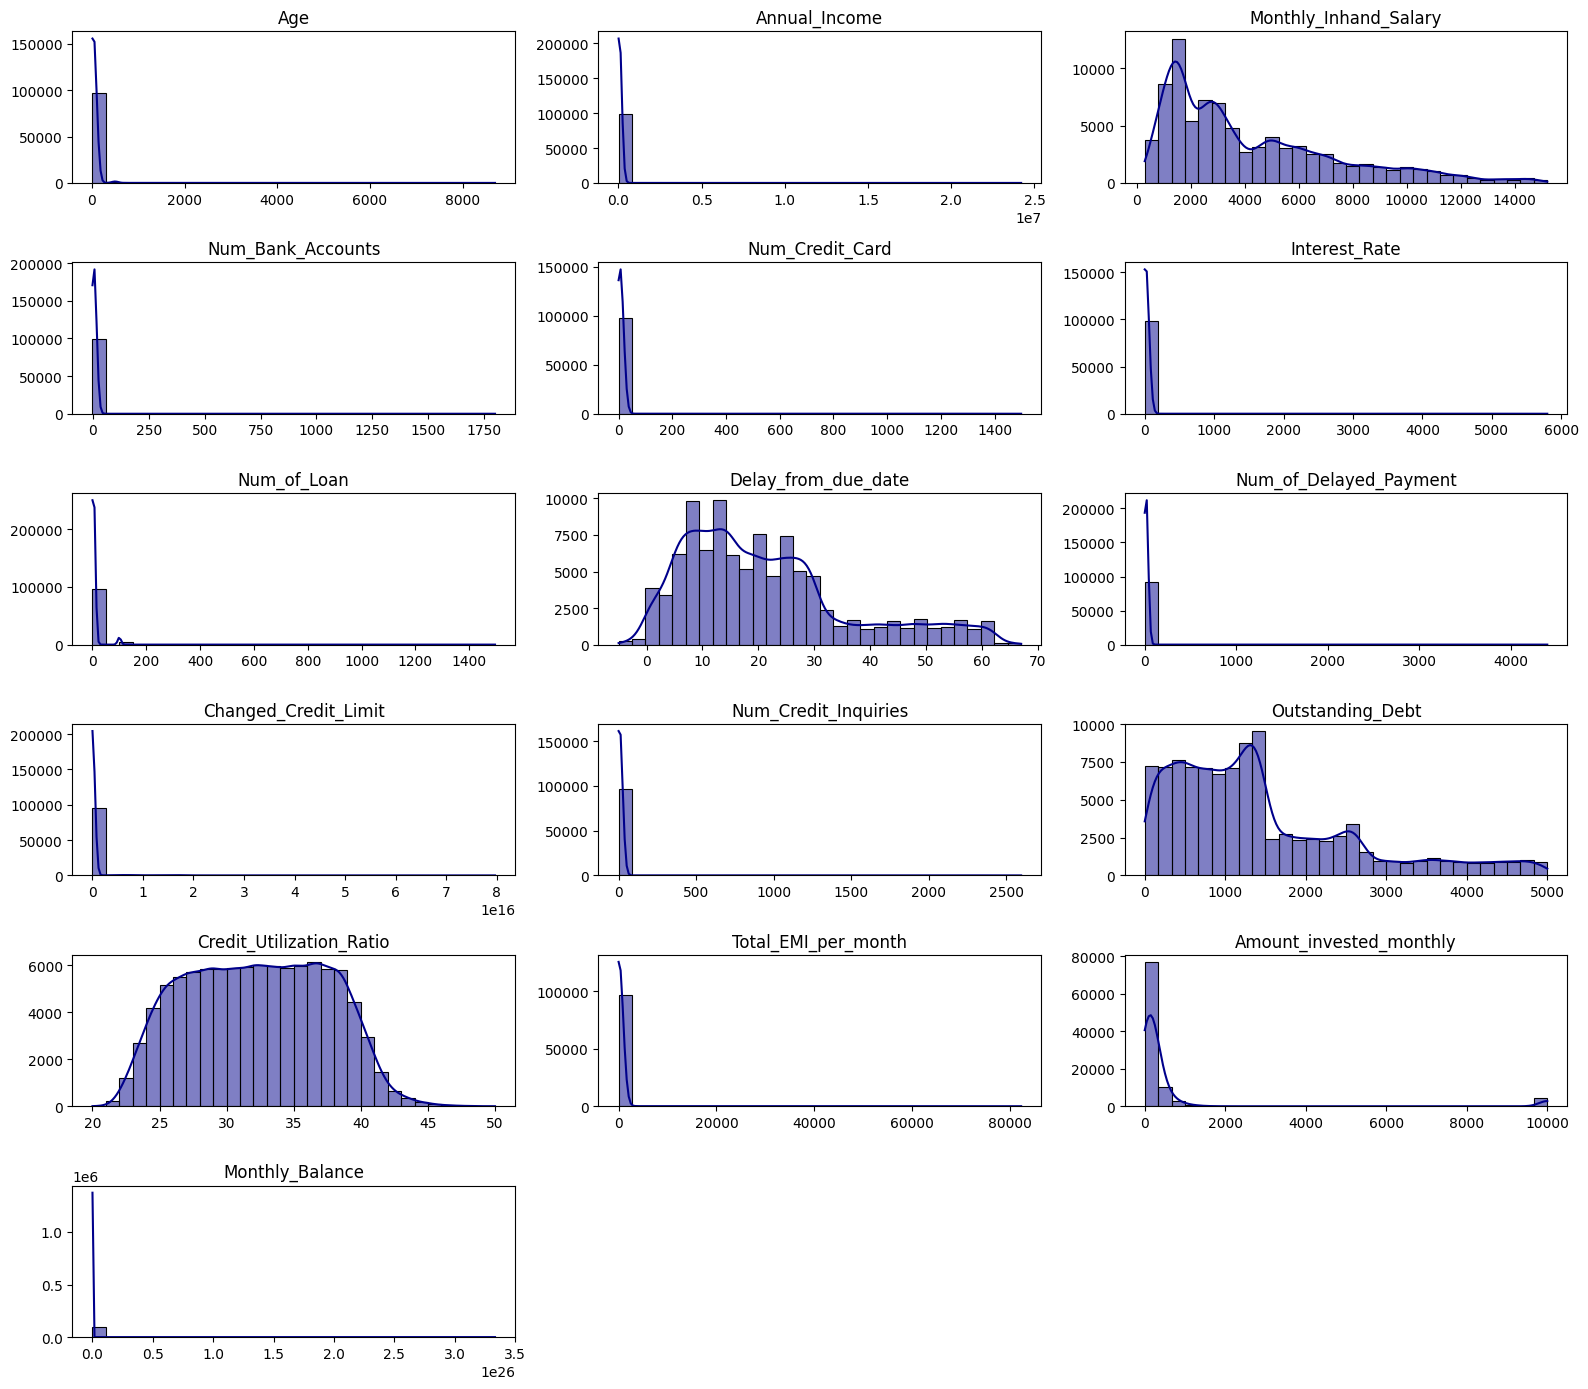

In [35]:
# Select numerical columns (excluding ID columns)
numerical_columns = train.select_dtypes(include=['float64', 'int64']).columns
numerical_columns = [col for col in numerical_columns if col not in ['ID', 'Customer_ID', 'SSN']]

# Plot histograms
plt.figure(figsize=(16, 14))

for i, col in enumerate(numerical_columns):
    plt.subplot((len(numerical_columns) + 2) // 3, 3, i + 1)  # Create grid of plots
    sns.histplot(train[col], bins=30, kde=True, color='darkblue')  # Histogram with KDE curve
    plt.title(col)
    plt.xlabel('')
    plt.ylabel('')

plt.tight_layout()
plt.show()

**insights:** These histograms are heavily skewed by outliers and don't give us a good understanding of the data distribution.

`->` Check for outliers in  numerical columns with **visual** and **statistical** methods.

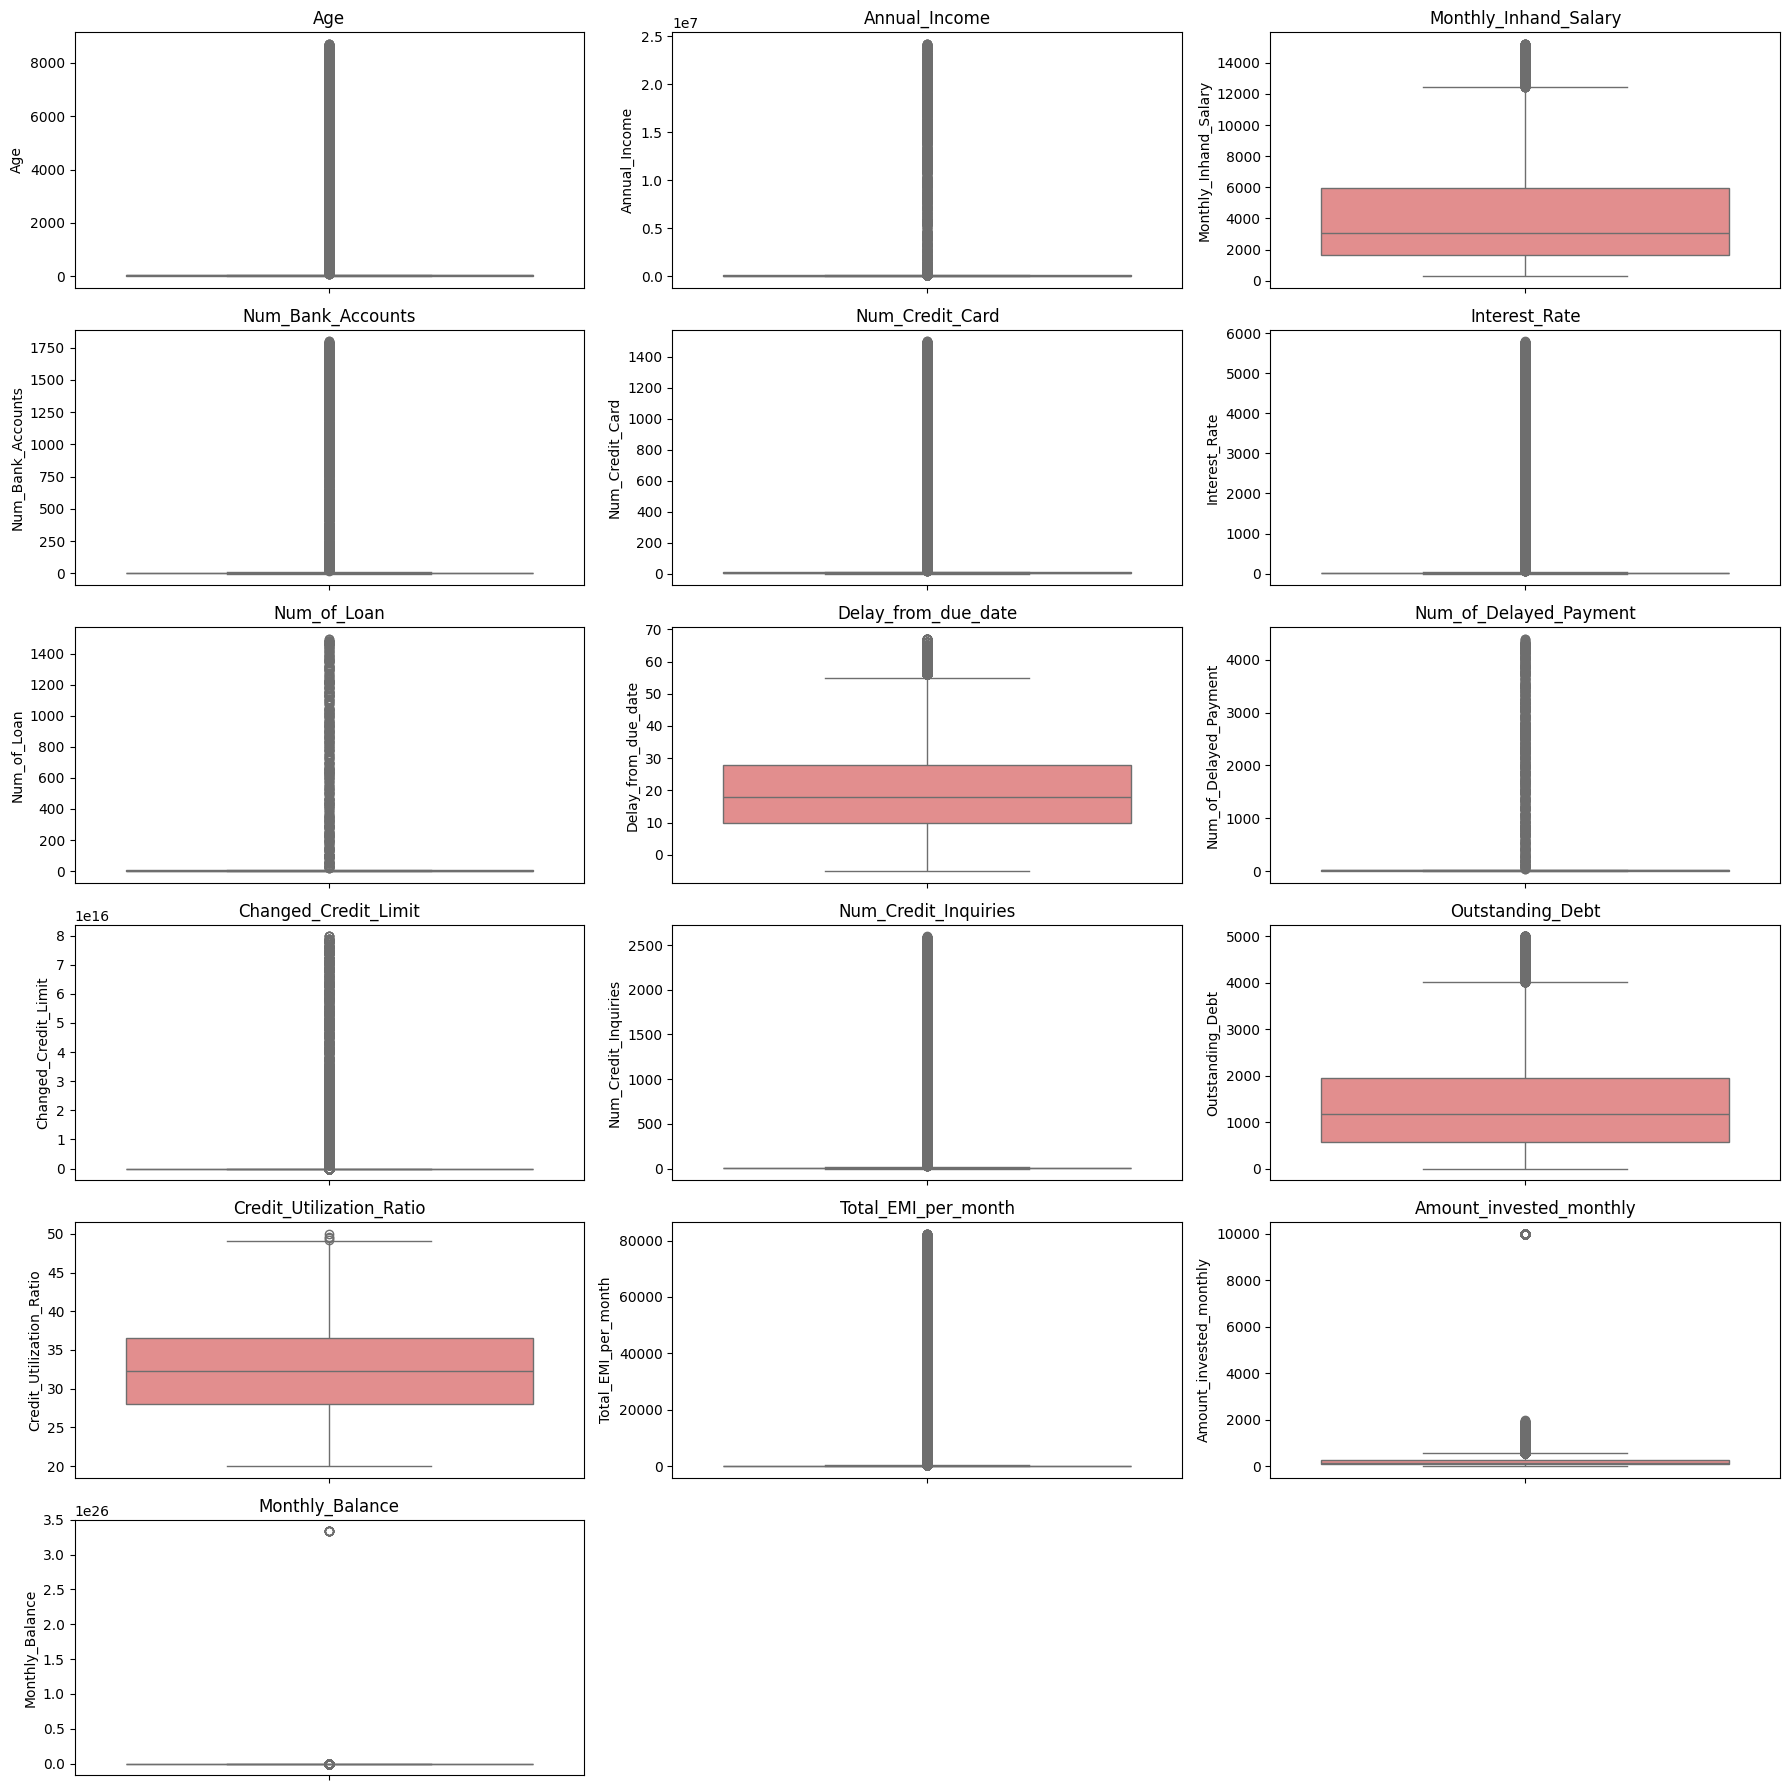

In [36]:
plt.figure(figsize=(18, 18))

n_cols = 3
n_rows = (len(numerical_columns) + n_cols - 1) // n_cols

for i, col in enumerate(numerical_columns):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.boxplot(data=train, y=col, color='lightcoral')
    plt.title(col)

plt.tight_layout()
plt.show()

In [37]:
for col in numerical_columns:
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = train[(train[col] < lower_bound) | (train[col] > upper_bound)]

    print(f"{col}: {len(outliers)} outliers")

Age: 2781 outliers
Annual_Income: 2783 outliers
Monthly_Inhand_Salary: 1683 outliers
Num_Bank_Accounts: 1315 outliers
Num_Credit_Card: 2271 outliers
Interest_Rate: 2034 outliers
Num_of_Loan: 4348 outliers
Delay_from_due_date: 4002 outliers
Num_of_Delayed_Payment: 736 outliers
Changed_Credit_Limit: 3068 outliers
Num_Credit_Inquiries: 1650 outliers
Outstanding_Debt: 5272 outliers
Credit_Utilization_Ratio: 4 outliers
Total_EMI_per_month: 6795 outliers
Amount_invested_monthly: 10096 outliers
Monthly_Balance: 7630 outliers


**Insights**
Extreme outliers dominate - the whiskers are barely visible, indicating most data is concentrated at very low values.


`->` check whether your categorical columns have balanced classe

In [38]:
#  Get categorical columns
categorical_columns = train.select_dtypes(include='object').columns

#  remove columns if present
categorical_columns = [col for col in categorical_columns if col not in ['ID', 'Customer_ID', 'SSN', 'Type_of_Loan', 'Credit_History_Age', 'Name', 'Month', 'Occupation', 'Credit_Score ']]

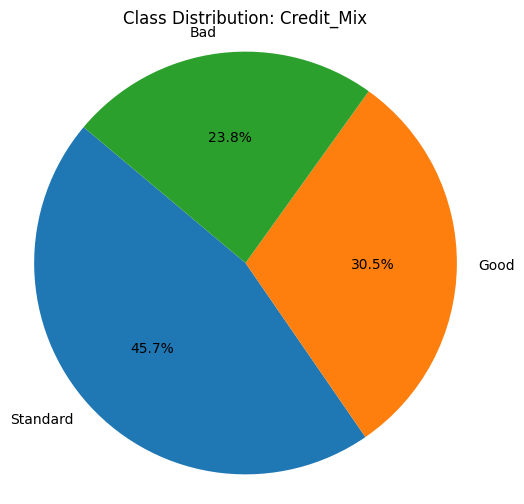

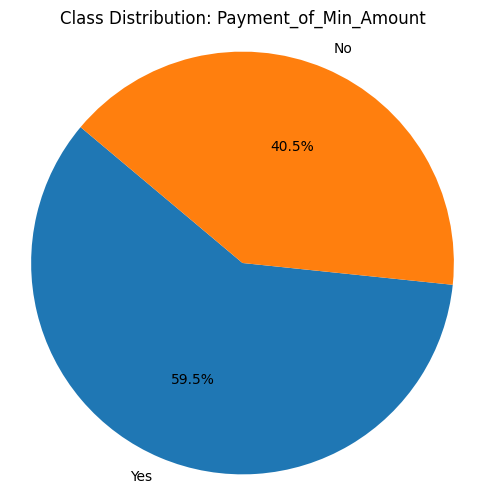

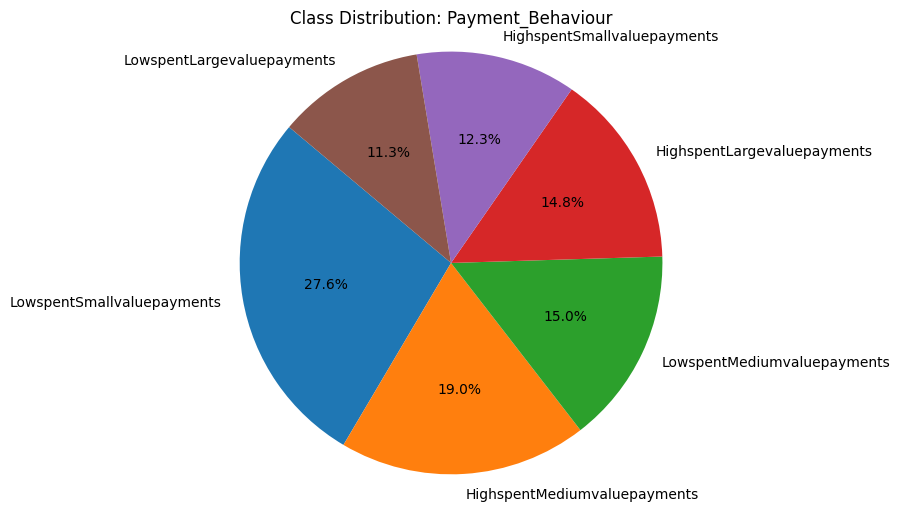

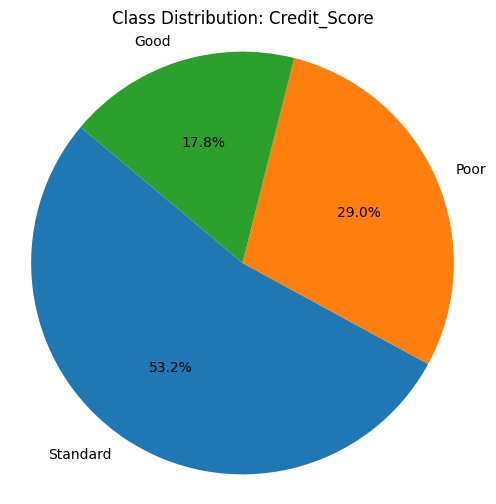

In [39]:
#  Plot pie chart for each categorical column
for col in categorical_columns:
    counts = train[col].value_counts()
    labels = counts.index
    sizes = counts.values

    plt.figure(figsize=(6, 6))
    plt.pie(
        sizes,
        labels=labels,
        autopct='%1.1f%%',
        startangle=140
    )
    plt.title(f"Class Distribution: {col}")
    plt.axis('equal')  # Equal aspect ratio ensures a circle
    plt.show()

In [40]:
for col in categorical_columns:
    print(f"\n{col} class distribution:")
    print(train[col].value_counts(normalize=True) * 100)


Credit_Mix class distribution:
Credit_Mix
Standard    45.710169
Good        30.495583
Bad         23.794248
Name: proportion, dtype: float64

Payment_of_Min_Amount class distribution:
Payment_of_Min_Amount
Yes    59.466094
No     40.533906
Name: proportion, dtype: float64

Payment_Behaviour class distribution:
Payment_Behaviour
LowspentSmallvaluepayments      27.611472
HighspentMediumvaluepayments    18.982684
LowspentMediumvaluepayments     15.001082
HighspentLargevaluepayments     14.849567
HighspentSmallvaluepayments     12.272727
LowspentLargevaluepayments      11.282468
Name: proportion, dtype: float64

Credit_Score class distribution:
Credit_Score
Standard    53.174
Poor        28.998
Good        17.828
Name: proportion, dtype: float64


Loan Type Percentages:
Payday Loan: 12.69%
Credit-Builder Loan: 12.60%
Home Equity Loan: 12.47%
Mortgage Loan: 12.46%
Personal Loan: 12.36%
Debt Consolidation Loan: 12.33%
Student Loan: 12.33%
Auto Loan: 12.14%
Not Specified: 0.62%


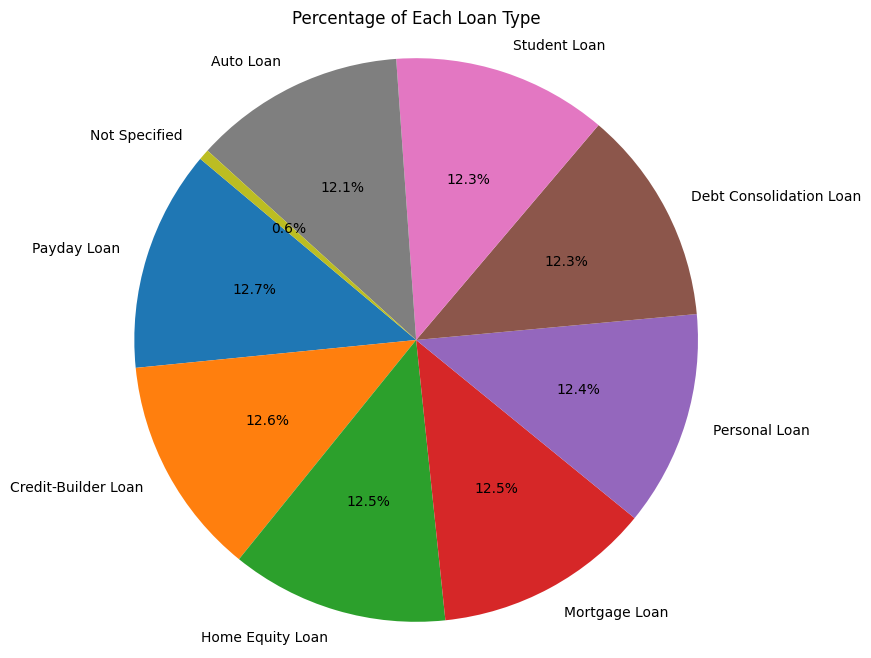

In [41]:
# Flatten the list of loan types, ignoring NaN values
all_loans = []
for loan_list in train['Type_of_Loan'].dropna():
    all_loans.extend(loan_list)

# Count occurrences of each loan type
loan_counts = pd.Series(all_loans).value_counts()
loan_percentages = loan_counts / loan_counts.sum() * 100

# Print percentages
print("Loan Type Percentages:")
for loan_type, pct in loan_percentages.items():
    print(f"{loan_type}: {pct:.2f}%")

# Plot pie chart
plt.figure(figsize=(8, 8))
plt.pie(
    loan_percentages,
    labels=loan_percentages.index,
    autopct='%1.1f%%',
    startangle=140
)
plt.title("Percentage of Each Loan Type")
plt.axis('equal')
plt.show()

----------------
# 04. Data preprocessing

## `i` Handling outliers

- Check the Percentage of Outliers (IQR Method)
    - If outliers are rare enough to remove/impute safely.
    - if they're too common to ignore (maybe they’re not outliers after all!).

In [42]:
def outlier_percentage(data, col, threshold ):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - threshold  * IQR
    upper = Q3 + threshold  * IQR
    outliers = data[(data[col] < lower) | (data[col] > upper)]
    percentage = 100 * len(outliers) / len(data)
    return percentage


In [43]:
numerical_columns = train.select_dtypes(include=['float64', 'int64']).columns
numerical_columns = [col for col in numerical_columns if col not in ['ID', 'Customer_ID', 'SSN']]

for col in numerical_columns:
    pct = outlier_percentage(train, col, 1.5)
    print(f"{col}: {pct:.2f}% outliers")


Age: 2.78% outliers
Annual_Income: 2.78% outliers
Monthly_Inhand_Salary: 1.68% outliers
Num_Bank_Accounts: 1.31% outliers
Num_Credit_Card: 2.27% outliers
Interest_Rate: 2.03% outliers
Num_of_Loan: 4.35% outliers
Delay_from_due_date: 4.00% outliers
Num_of_Delayed_Payment: 0.74% outliers
Changed_Credit_Limit: 3.07% outliers
Num_Credit_Inquiries: 1.65% outliers
Outstanding_Debt: 5.27% outliers
Credit_Utilization_Ratio: 0.00% outliers
Total_EMI_per_month: 6.79% outliers
Amount_invested_monthly: 10.10% outliers
Monthly_Balance: 7.63% outliers


In [44]:
# Find the maximum and min value for each numerical column in train
for col in numerical_columns:
    max_value = train[col].max()
    min_value = train[col].min()
    print(f"{col} - Max: {max_value}, Min: {min_value}")

Age - Max: 8698, Min: 14
Annual_Income - Max: 24198062.0, Min: 7005.93
Monthly_Inhand_Salary - Max: 15204.633333333331, Min: 303.6454166666666
Num_Bank_Accounts - Max: 1798, Min: -1
Num_Credit_Card - Max: 1499, Min: 0
Interest_Rate - Max: 5797, Min: 1
Num_of_Loan - Max: 1496, Min: 0
Delay_from_due_date - Max: 67, Min: -5
Num_of_Delayed_Payment - Max: 4397.0, Min: 0.0
Changed_Credit_Limit - Max: 7.970000000000002e+16, Min: 0.0
Num_Credit_Inquiries - Max: 2597.0, Min: 0.0
Outstanding_Debt - Max: 4998.07, Min: 0.23
Credit_Utilization_Ratio - Max: 50.00000000000001, Min: 20.0
Total_EMI_per_month - Max: 82331.0, Min: 0.0
Amount_invested_monthly - Max: 10000.0, Min: 0.0
Monthly_Balance - Max: 3.333333333333333e+26, Min: 0.0077596647753352


In [45]:
# handle negative values where they don’t make sense, fill it with null
for col in numerical_columns:
    train.loc[train[col] < 0, col] = np.nan

In [46]:
cap_cols = ['Age', 'Monthly_Inhand_Salary', 'Num_Credit_Card', 'Num_Bank_Accounts',
             'Interest_Rate', 'Num_of_Loan',  'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries',
             'Total_EMI_per_month', 'Monthly_Balance', 'Amount_invested_monthly', 'Annual_Income']

In [47]:
def cap_outliers(data, col, threshold=1.5):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - threshold * IQR
    upper = Q3 + threshold * IQR
    data[col] = data[col].clip(lower, upper)
    return data

In [48]:
for col in cap_cols:
    if col in ['Monthly_Balance', 'Amount_invested_monthly', 'Annual_Income']:
        train = cap_outliers(train, col, threshold=2)
    else:
        train = cap_outliers(train, col)

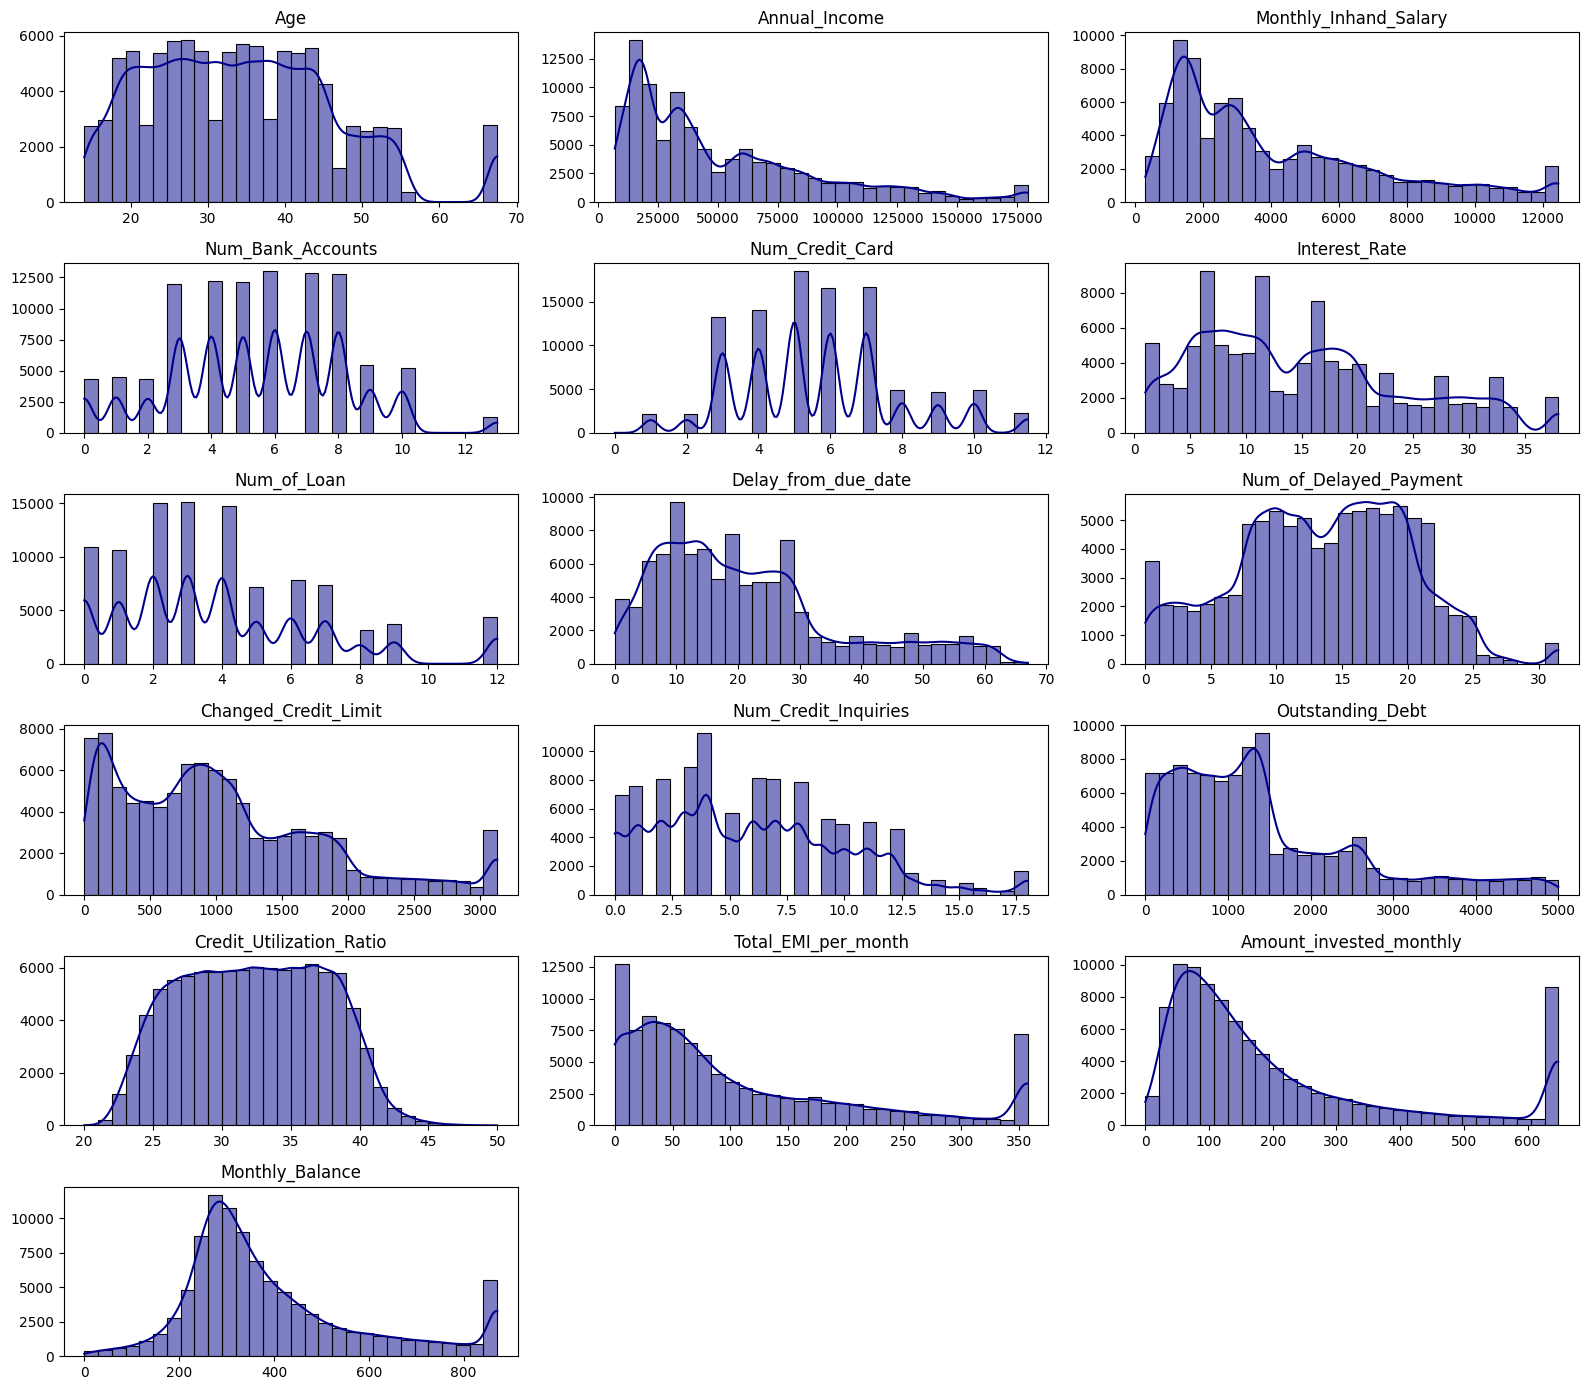

In [49]:
# Plot histograms
plt.figure(figsize=(16, 14))

for i, col in enumerate(numerical_columns):
    plt.subplot((len(numerical_columns) + 2) // 3, 3, i + 1)  # Create grid of plots
    sns.histplot(train[col], bins=30, kde=True, color='darkblue')  # Histogram with KDE curve
    plt.title(col)
    plt.xlabel('')
    plt.ylabel('')

plt.tight_layout()
plt.show()

## `ii` Handling missing data
- **Drop Rows**	When missing % is very low (<5%)
-  Fill with **Mean/Median/Mode**
    - Mean: Data is normally distributed
    - Median: Data is skewed or contains outliers

- Forward/Backward Fill
- Drop Columns

In [50]:
# check for missing values in the train dataset
missing = train.isnull().sum()
missing_percentage = (missing / len(train)) * 100
print(missing_percentage[missing_percentage > 0].sort_values(ascending=False))

Credit_Mix                 20.195
Monthly_Inhand_Salary      15.002
Payment_of_Min_Amount      12.007
Type_of_Loan               11.408
Name                        9.985
Credit_History_Age          9.030
Payment_Behaviour           7.600
Occupation                  7.062
Num_of_Delayed_Payment      7.002
Amount_invested_monthly     4.479
Changed_Credit_Limit        2.091
Num_Credit_Inquiries        1.965
Monthly_Balance             1.200
Delay_from_due_date         0.591
Num_Bank_Accounts           0.021
dtype: float64


In [51]:
# handel Credit_Mix missing values
train['Credit_Mix'].unique()

array([nan, 'Good', 'Standard', 'Bad'], dtype=object)

In [52]:
# Random filling method based on value distribution
def random_fill_categorical(df, col):
    probs = df[col].value_counts(normalize=True)
    missing_mask = df[col].isnull()
    df.loc[missing_mask, col] = np.random.choice(
        probs.index, size=missing_mask.sum(), p=probs.values
        )

In [53]:
# Apply random filling to the 'Credit_Mix' column
random_fill_categorical(train, 'Credit_Mix')

# Check the unique values and missing count after random filling
print(train['Credit_Mix'].unique())
print("Number of missing values in 'Credit_Mix':", train['Credit_Mix'].isnull().sum())

['Good' 'Bad' 'Standard']
Number of missing values in 'Credit_Mix': 0


In [54]:
#  Apply random filling to the 'Occupation' column
random_fill_categorical(train, 'Occupation')

# Check the unique values and missing count after random filling
print(train['Occupation'].unique())
print("Number of missing values in 'Occupation':", train['Occupation'].isnull().sum())

['Scientist' 'Engineer' 'Teacher' 'Journalist' 'Architect' 'Lawyer'
 'Entrepreneur' 'Musician' 'Developer' 'MediaManager' 'Manager'
 'Accountant' 'Doctor' 'Mechanic' 'Writer']
Number of missing values in 'Occupation': 0


In [55]:
# group-wise median for Monthly_Inhand_Salary
train['Monthly_Inhand_Salary'] = train.groupby('Occupation')['Monthly_Inhand_Salary'].transform(
    lambda x: x.fillna(x.median())
)

# Check of the missing values in 'Monthly_Inhand_Salary' after filling
print("Number of missing values in 'Monthly_Inhand_Salary':", train['Monthly_Inhand_Salary'].isnull().sum())

Number of missing values in 'Monthly_Inhand_Salary': 0


In [56]:
#  Apply random filling to the 'Payment_of_Min_Amount' column
random_fill_categorical(train, 'Payment_of_Min_Amount')

# Check the missing count after random filling
print("Number of missing values in 'Payment_of_Min_Amount':", train['Payment_of_Min_Amount'].isnull().sum())

Number of missing values in 'Payment_of_Min_Amount': 0


In [57]:
# Fill NaN values in the column 'Type_of_Loan' with ['Not Specified']
train['Type_of_Loan'] = train['Type_of_Loan'].apply(
    lambda x: x if isinstance(x, list) else ['Not Specified']
)
print(train['Type_of_Loan'].isnull().sum())

0


In [58]:
# drop Name coulmn
train = train.drop(columns=['Name'])

In [59]:
# Credit_History_Age to Credit_History_Months conversion
# Assuming 'Credit_History_Age' is a string in the format "X Years and Y Months"

# Convert this string to a numeric value
def convert_to_months(value):
    if pd.isnull(value):
        return np.nan
    match = re.match(r'(\d+)\s+Years\s+and\s+(\d+)\s+Months', value)
    if match:
        years = int(match.group(1))
        months = int(match.group(2))
        return years * 12 + months
    return np.nan

# Apply conversion
train['Credit_History_Months'] = train['Credit_History_Age'].apply(convert_to_months)

In [60]:
# Fill missing with median
median_months = train['Credit_History_Months'].median()
train['Credit_History_Months'].fillna(median_months, inplace=True)

print("Number of missing values in 'Credit_History_Months':", train['Credit_History_Months'].isnull().sum())

Number of missing values in 'Credit_History_Months': 0


In [61]:
train.drop(columns=['Credit_History_Age'], inplace=True)

In [62]:
#  Apply random filling to the 'Payment_of_Min_Amount' column
random_fill_categorical(train, 'Payment_Behaviour')

# Check the missing count after random filling
print("Number of missing values in 'Payment_Behaviour':", train['Payment_Behaviour'].isnull().sum())

Number of missing values in 'Payment_Behaviour': 0


In [63]:
# Fill missing with median to the 'Num_of_Delayed_Payment' column
median_months = train['Num_of_Delayed_Payment'].median()
train['Num_of_Delayed_Payment'].fillna(median_months, inplace=True)

print("Number of missing values in 'Num_of_Delayed_Payment':", train['Num_of_Delayed_Payment'].isnull().sum())

Number of missing values in 'Num_of_Delayed_Payment': 0


In [64]:
# Fill missing with median to the 'Num_of_Delayed_Payment' column
median_months = train['Amount_invested_monthly'].median()
train['Amount_invested_monthly'].fillna(median_months, inplace=True)

print("Number of missing values in 'Amount_invested_monthly':", train['Amount_invested_monthly'].isnull().sum())

Number of missing values in 'Amount_invested_monthly': 0


In [65]:
# Fill missing with median to the 'Num_of_Delayed_Payment' column
median_months = train['Changed_Credit_Limit'].median()
train['Changed_Credit_Limit'].fillna(median_months, inplace=True)

print("Number of missing values in 'Changed_Credit_Limit':", train['Changed_Credit_Limit'].isnull().sum())

Number of missing values in 'Changed_Credit_Limit': 0


In [66]:
# Fill missing with median to the 'Num_of_Delayed_Payment' column
median_months = train['Num_Credit_Inquiries'].median()
train['Num_Credit_Inquiries'].fillna(median_months, inplace=True)

print("Number of missing values in 'Num_Credit_Inquiries':", train['Num_Credit_Inquiries'].isnull().sum())

Number of missing values in 'Num_Credit_Inquiries': 0


In [67]:
# Fill missing with median to the 'Num_of_Delayed_Payment' column
median_months = train['Monthly_Balance'].median()
train['Monthly_Balance'].fillna(median_months, inplace=True)

print("Number of missing values in 'Monthly_Balance':", train['Monthly_Balance'].isnull().sum())

Number of missing values in 'Monthly_Balance': 0


In [68]:
# Fill missing with median to the 'Num_of_Delayed_Payment' column
median_months = train['Delay_from_due_date'].median()
train['Delay_from_due_date'].fillna(median_months, inplace=True)

print("Number of missing values in 'Delay_from_due_date':", train['Delay_from_due_date'].isnull().sum())

Number of missing values in 'Delay_from_due_date': 0


In [69]:
# Fill missing with median to the 'Num_of_Delayed_Payment' column
median_months = train['Num_Bank_Accounts'].median()
train['Num_Bank_Accounts'].fillna(median_months, inplace=True)

print("Number of missing values in 'Num_Bank_Accounts':", train['Num_Bank_Accounts'].isnull().sum())

Number of missing values in 'Num_Bank_Accounts': 0


In [70]:
train.isnull().sum()

,0
ID,0
Customer_ID,0
Month,0
Age,0
SSN,0
Occupation,0
Annual_Income,0
Monthly_Inhand_Salary,0
Num_Bank_Accounts,0
Num_Credit_Card,0


## `iii` Feature Selection
- Highly Correlated Features (Multicollinearity)


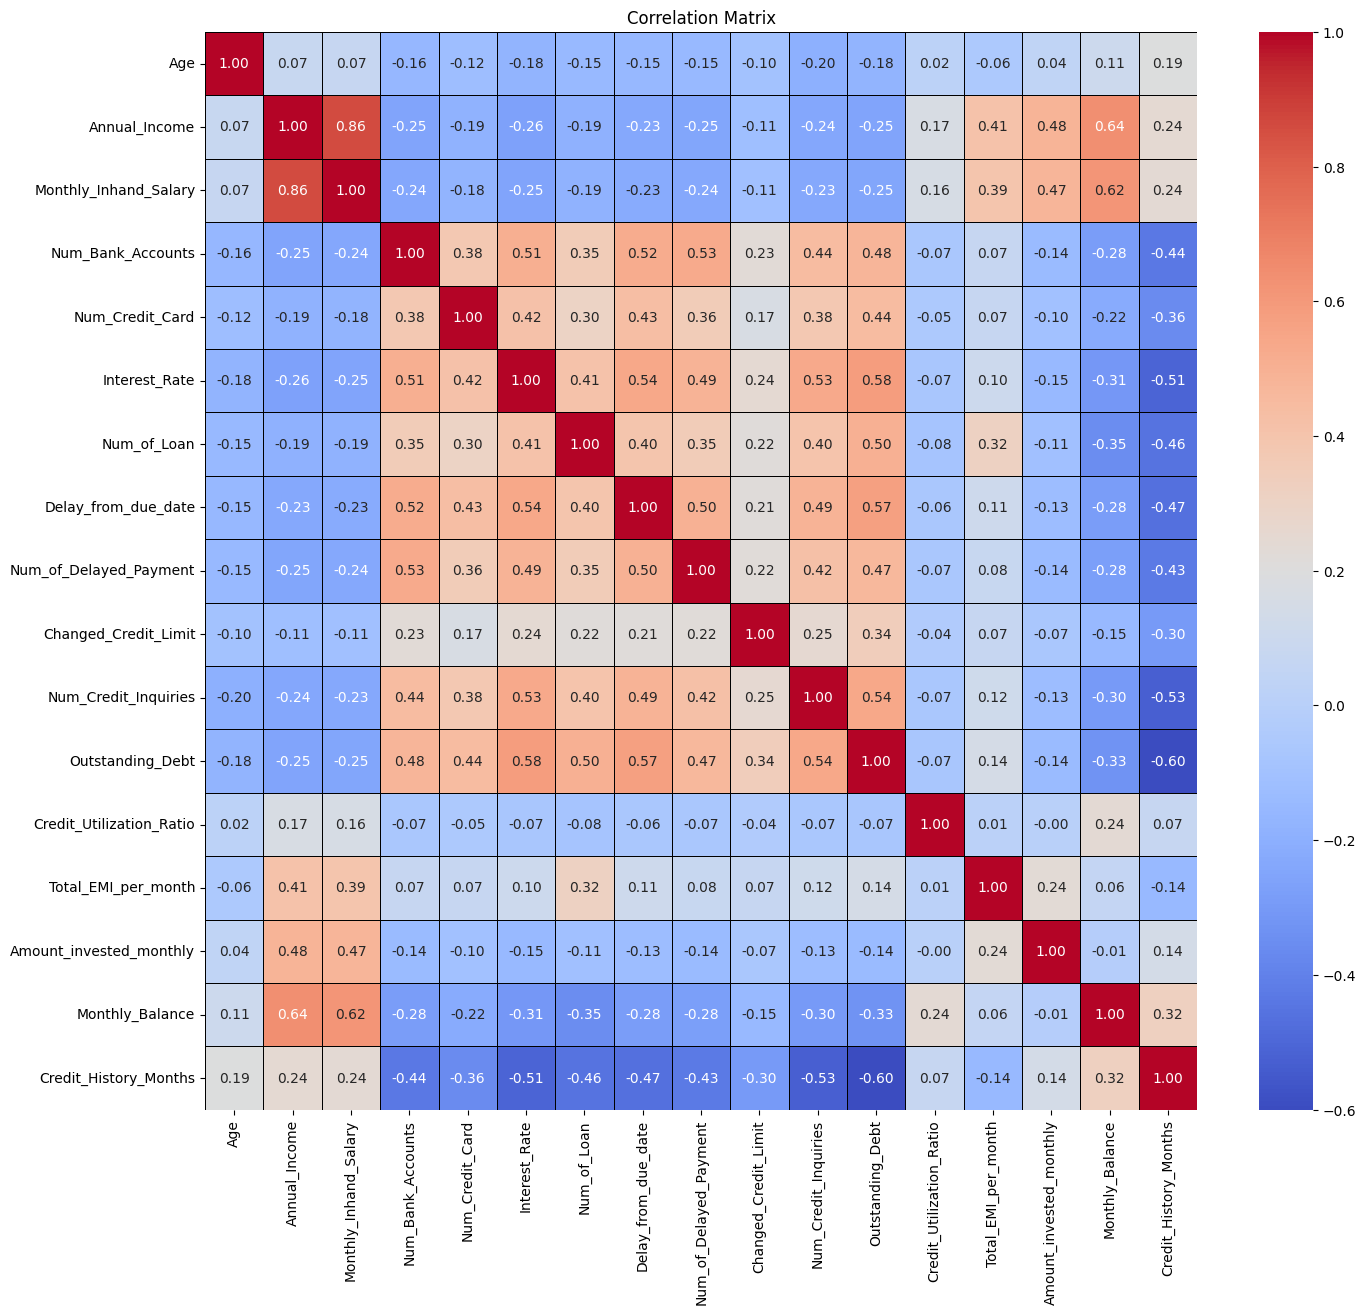

In [71]:
# correlation matrix
integer_columns = train.select_dtypes(include=['int64', 'float64']).columns
integer_columns = [col for col in integer_columns if col not in ['ID', 'Customer_ID', 'SSN']]

plt.figure(figsize=(16, 14))
sns.heatmap(train[integer_columns].corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5, linecolor='black')
plt.title("Correlation Matrix")
plt.show()

In [72]:
highly_correlated_cols = ['Monthly_Inhand_Salary', 'Num_Credit_Card', 'Delay_from_due_date', 'Outstanding_Debt']
# Drop highly correlated columns
train = train.drop(columns=highly_correlated_cols)

## `iiii` Encode Categoricals


In [73]:
categorical_columns = train.select_dtypes(include='object').columns.tolist()
categorical_columns = [col for col in categorical_columns if col not in ['ID', 'Customer_ID', 'SSN', 'Type_of_Loan' ,'Credit_History_Age', 'Name', 'Month', 'Credit_Score ']]

for col in categorical_columns:
    print(f"Unique values: {train[col].unique()}")

Unique values: ['Scientist' 'Engineer' 'Teacher' 'Journalist' 'Architect' 'Lawyer'
 'Entrepreneur' 'Musician' 'Developer' 'MediaManager' 'Manager'
 'Accountant' 'Doctor' 'Mechanic' 'Writer']
Unique values: ['Good' 'Bad' 'Standard']
Unique values: ['No' 'Yes']
Unique values: ['HighspentSmallvaluepayments' 'LowspentLargevaluepayments'
 'LowspentMediumvaluepayments' 'LowspentSmallvaluepayments'
 'HighspentMediumvaluepayments' 'HighspentLargevaluepayments']
Unique values: ['Good' 'Standard' 'Poor']


In [74]:
onehot_encode_list = ['Occupation', 'Payment_Behaviour']

#  Initialize encoder
onehot_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

#  Fit and transform the selected categorical columns
onehot_encoded = onehot_encoder.fit_transform(train[onehot_encode_list])

# Get feature names for the one-hot columns
encoded_cols = onehot_encoder.get_feature_names_out(onehot_encode_list)

# Convert the result to a DataFrame
onehot_df = pd.DataFrame(onehot_encoded, columns=encoded_cols, index=train.index)

# Concatenate with original dataframe (drop original encoded columns)
train = pd.concat([train.drop(columns=onehot_encode_list), onehot_df], axis=1)

In [75]:
#  Define the order
ordinal_encoder = OrdinalEncoder(categories=[['Bad', 'Standard', 'Good']])

# Fit and transform
train['Credit_Mix'] = ordinal_encoder.fit_transform(train[['Credit_Mix']])

In [76]:
label_encode_list = ['Credit_Score', 'Payment_of_Min_Amount']

for col in label_encode_list:
    le = LabelEncoder()
    train[col] = le.fit_transform(train[col].astype(str))

In [77]:
mlb = MultiLabelBinarizer()
loan_encoded = mlb.fit_transform(train['Type_of_Loan'])

# Create a DataFrame with the new columns
loan_df = pd.DataFrame(loan_encoded, columns=mlb.classes_, index=train.index)

# Concatenate with original dataset
train = pd.concat([train.drop(columns=['Type_of_Loan']), loan_df], axis=1)

In [78]:
train.columns

Index(['ID', 'Customer_ID', 'Month', 'Age', 'SSN', 'Annual_Income',
       'Num_Bank_Accounts', 'Interest_Rate', 'Num_of_Loan',
       'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Credit_Utilization_Ratio',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Monthly_Balance', 'Credit_Score',
       'Credit_History_Months', 'Occupation_Accountant',
       'Occupation_Architect', 'Occupation_Developer', 'Occupation_Doctor',
       'Occupation_Engineer', 'Occupation_Entrepreneur',
       'Occupation_Journalist', 'Occupation_Lawyer', 'Occupation_Manager',
       'Occupation_Mechanic', 'Occupation_MediaManager', 'Occupation_Musician',
       'Occupation_Scientist', 'Occupation_Teacher', 'Occupation_Writer',
       'Payment_Behaviour_HighspentLargevaluepayments',
       'Payment_Behaviour_HighspentMediumvaluepayments',
       'Payment_Behaviour_HighspentSmallvaluepayments',
       'Payment_Behaviour_Lows

In [79]:
drop_columns = ['ID', 'Customer_ID', 'Month', 'SSN']
train = train.drop(columns=drop_columns)

In [80]:
train.head()

,Age,Annual_Income,Num_Bank_Accounts,Interest_Rate,Num_of_Loan,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Credit_Utilization_Ratio,...,Payment_Behaviour_LowspentSmallvaluepayments,Auto Loan,Credit-Builder Loan,Debt Consolidation Loan,Home Equity Loan,Mortgage Loan,Not Specified,Payday Loan,Personal Loan,Student Loan
0,23.0,19114.12,3.0,3.0,4.0,7.0,1127.0,4.0,2.0,26.822620,...,0.0,1,1,0,1,0,0,0,1,0
1,23.0,19114.12,3.0,3.0,4.0,14.0,1127.0,4.0,2.0,31.944960,...,0.0,1,1,0,1,0,0,0,1,0
2,67.5,19114.12,3.0,3.0,4.0,7.0,901.0,4.0,2.0,28.609352,...,0.0,1,1,0,1,0,0,0,1,0
3,23.0,19114.12,3.0,3.0,4.0,4.0,627.0,4.0,2.0,31.377862,...,1.0,1,1,0,1,0,0,0,1,0
4,23.0,19114.12,3.0,3.0,4.0,14.0,1127.0,4.0,2.0,24.797347,...,0.0,1,1,0,1,0,0,0,1,0


## `iiiii` Split the Data

In [81]:
X = train.drop(columns=['Credit_Score'])
y = train['Credit_Score']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

----------------
# 05. Model selection and training

In [82]:
# Define models with pipelines
models = {
    "RandomForest": Pipeline([
        ('classifier', RandomForestClassifier())
    ]),
    "LogisticRegression": Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', LogisticRegression())
    ]),
    "XGBoost": Pipeline([
        ('classifier', XGBClassifier(eval_metric="mlogloss"))
    ]),
}

# Dictionary to store accuracy results
accuracy_results = {}
results = []

# Loop over models
for name, pipeline in models.items():
    # Fit the model
    pipeline.fit(X_train, y_train)

    # Predict on test set
    y_pred = pipeline.predict(X_test)

    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)

    # Instantiate a KFold object
    kf = KFold(n_splits=5, random_state=12, shuffle=True)

    # Perform cross-validation
    cv_results = cross_val_score(pipeline, X_train, y_train, cv=kf)
    results.append(cv_results)

    # Store result
    accuracy_results[name] = accuracy
    print(f"\n{name} Accuracy: {accuracy:.4f}")



RandomForest Accuracy: 0.7698

LogisticRegression Accuracy: 0.6147

XGBoost Accuracy: 0.7304


## Tuning for RandomForest

In [90]:
# Tuning RandomForestClassifier
rf_param_grid = {
    'classifier__n_estimators': [100, 200, 300, 400, 500],
    'classifier__max_depth': [10, 15, 20, 25, None],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__bootstrap': [True, False],
    'classifier__criterion': ['gini', 'entropy']
}

rf_random_search = RandomizedSearchCV(
    estimator=models['RandomForest'],
    param_distributions=rf_param_grid,
    n_iter=10, # Number of parameter settings that are sampled
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1,
    scoring='accuracy' # Or 'f1_macro', 'f1_weighted' etc.
)

# Fit RandomizedSearchCV to the training data
rf_random_search.fit(X_train, y_train)

# Print the best parameters and the best score
print("Best parameters found for RandomForestClassifier:")
print(rf_random_search.best_params_)
print("Best cross-validation accuracy:")
print(rf_random_search.best_score_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best parameters found for RandomForestClassifier:
{'classifier__n_estimators': 400, 'classifier__min_samples_split': 2, 'classifier__min_samples_leaf': 1, 'classifier__max_depth': 25, 'classifier__criterion': 'gini', 'classifier__bootstrap': False}
Best cross-validation accuracy:
0.7651


In [91]:
# Evaluate the best model on the test set
best_rf_model = rf_random_search.best_estimator_
y_pred_rf_tuned = best_rf_model.predict(X_test)
accuracy_rf_tuned = accuracy_score(y_test, y_pred_rf_tuned)

print(f"\nTuned RandomForestClassifier Test Accuracy: {accuracy_rf_tuned:.4f}")
print("Classification Report for Tuned RandomForestClassifier:")
print(classification_report(y_test, y_pred_rf_tuned))
print("Confusion Matrix for Tuned RandomForestClassifier:")
print(confusion_matrix(y_test, y_pred_rf_tuned))


Tuned RandomForestClassifier Test Accuracy: 0.7801
Classification Report for Tuned RandomForestClassifier:
              precision    recall  f1-score   support

           0       0.72      0.71      0.71      3566
           1       0.78      0.77      0.78      5799
           2       0.80      0.81      0.80     10635

    accuracy                           0.78     20000
   macro avg       0.77      0.76      0.77     20000
weighted avg       0.78      0.78      0.78     20000

Confusion Matrix for Tuned RandomForestClassifier:
[[2534   13 1019]
 [ 183 4474 1142]
 [ 806 1235 8594]]


In [92]:
f1 = f1_score(y_test, y_pred_rf_tuned, average='weighted')
print(f"Tuned RandomForestClassifier F1 Score: {f1:.4f}")

Tuned RandomForestClassifier F1 Score: 0.7800


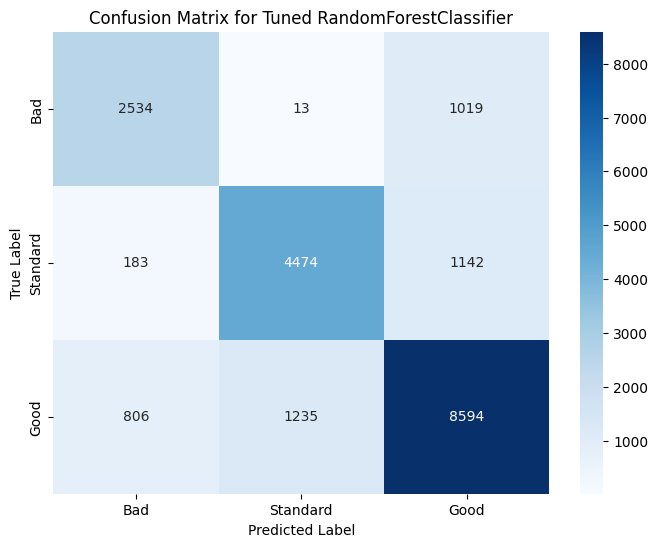

In [94]:
# Plot confusion matrix for the tuned RandomForestClassifier
cm_rf_tuned = confusion_matrix(y_test, y_pred_rf_tuned)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf_tuned, annot=True, fmt='d', cmap='Blues', xticklabels=['Bad', 'Standard', 'Good'], yticklabels=['Bad', 'Standard', 'Good'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Tuned RandomForestClassifier')
plt.show()


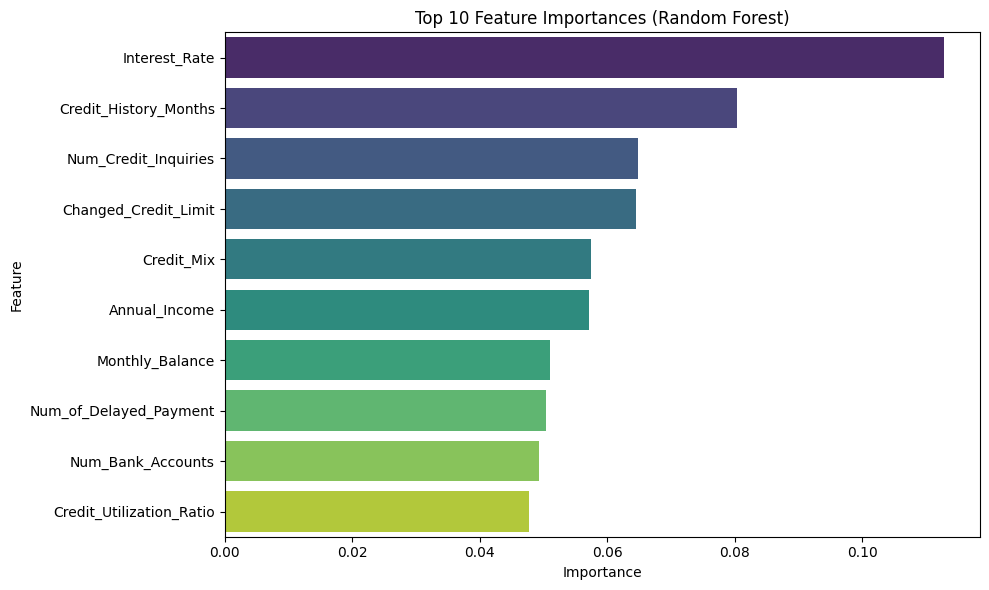

In [95]:
rf_model = best_rf_model.named_steps['classifier']

# Get feature importances
feature_importances = rf_model.feature_importances_

# Create a pandas Series for easier handling
feature_importance_series = pd.Series(feature_importances, index=X_train.columns)

# Sort feature importances and select the top 10
top_10_features = feature_importance_series.sort_values(ascending=False).head(10)

# Plot the top 10 feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x=top_10_features.values, y=top_10_features.index, palette='viridis')
plt.title('Top 10 Feature Importances (Random Forest)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## Tuning for XGBoost

In [83]:
# Hyperparameter Tuning for XGBoost
# Define hyperparameter grid
param_grid = {
    "n_estimators": [50, 100, 200, 300],
    "max_depth": [3, 5, 7, 10],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "gamma": [0, 0.1, 0.3, 0.5],
    "reg_lambda": [0.1, 1, 10],
    "reg_alpha": [0, 0.1, 1]
}

# Initialize XGBoost model
xgb = XGBClassifier(eval_metric="mlogloss", random_state=42)

# Randomized search
random_search = RandomizedSearchCV(
    xgb, param_distributions=param_grid,
    n_iter=10, scoring="accuracy",
    cv=5, verbose=2, n_jobs=-1, random_state=42
)

# Fit on training data
random_search.fit(X_train, y_train)

# Best hyperparameters
print("Best Hyperparameters:", random_search.best_params_)

# Evaluate with best model
best_xgb = random_search.best_estimator_
accuracy = best_xgb.score(X_test, y_test)
print("Tuned XGBoost Accuracy:", accuracy)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Hyperparameters: {'reg_lambda': 10, 'reg_alpha': 0.1, 'n_estimators': 100, 'max_depth': 10, 'learning_rate': 0.2, 'gamma': 0.1}
Tuned XGBoost Accuracy: 0.7566


In [84]:
eval_set = [(X_train, y_train), (X_test, y_test)]
best_xgb.fit(X_train, y_train, eval_set=eval_set, verbose=False)
y_pred = best_xgb.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7566


In [93]:
f1 = f1_score(y_test, y_pred, average='weighted')
print(f"Tuned RandomForestClassifier F1 Score: {f1:.4f}")

Tuned RandomForestClassifier F1 Score: 0.7566


In [85]:
# Print classification report
print(f"Classification Report for XGBoost:")
print(classification_report(y_test, y_pred))

Classification Report for XGBoost:
              precision    recall  f1-score   support

           0       0.66      0.69      0.68      3566
           1       0.77      0.72      0.75      5799
           2       0.78      0.80      0.79     10635

    accuracy                           0.76     20000
   macro avg       0.74      0.74      0.74     20000
weighted avg       0.76      0.76      0.76     20000



[[2461   24 1081]
 [ 298 4201 1300]
 [ 953 1212 8470]]


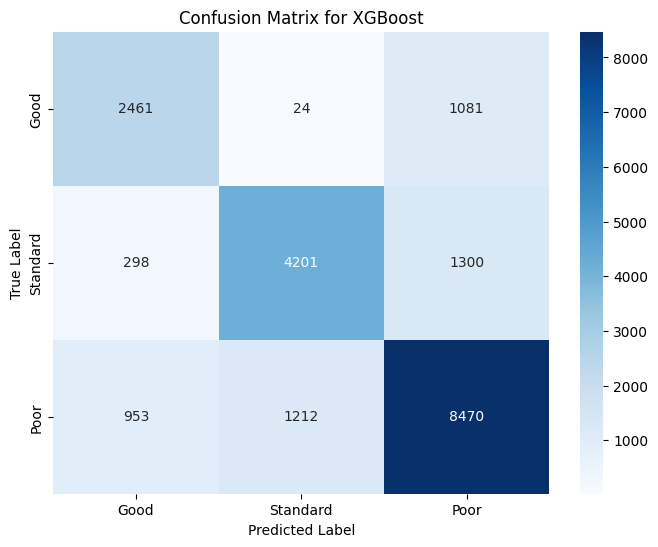

In [89]:
# Generate confusion matrix
cm_xgb = confusion_matrix(y_test, y_pred)
print(cm_xgb)

class_labels = ['Good' ,'Standard', 'Poor']

# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(cm_xgb, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels)

# Labels and title
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix for XGBoost")

# Show the plot
plt.show()

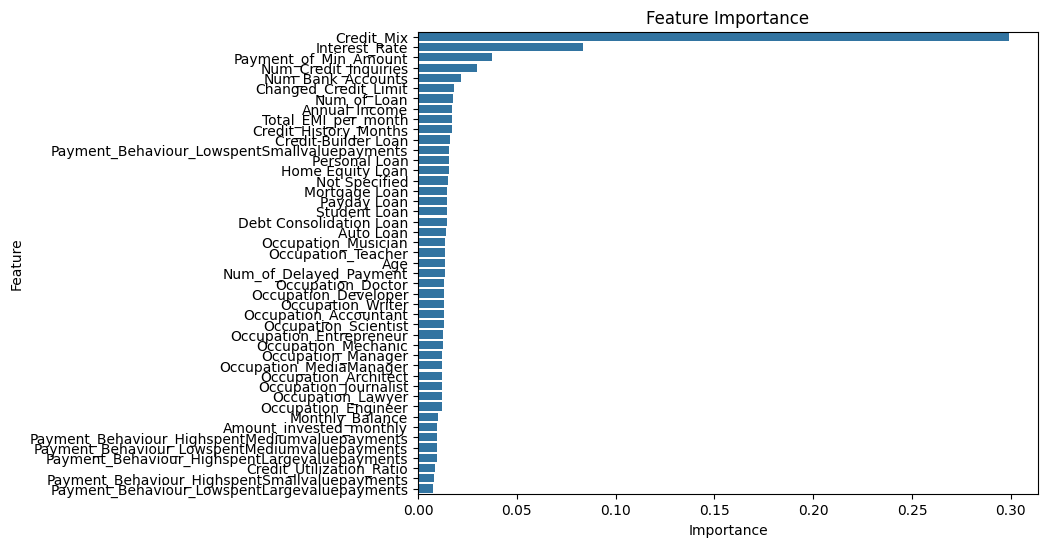

In [87]:
# Extract feature importance
feature_importance = best_xgb.feature_importances_

# Convert to DataFrame
feat_imp_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': feature_importance})

# Sort by importance
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False)

# Plot using seaborn
plt.figure(figsize=(8, 6))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df)
plt.title("Feature Importance")
plt.show()